In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from DoE_module import t as sp_t
import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercep="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

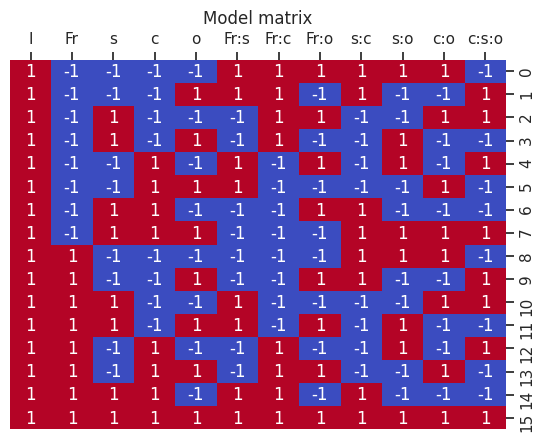

In [ ]:
M = pd.read_csv("matrix_model.csv")
show_matrix(M)
plt.title("Model matrix")
plt.show()

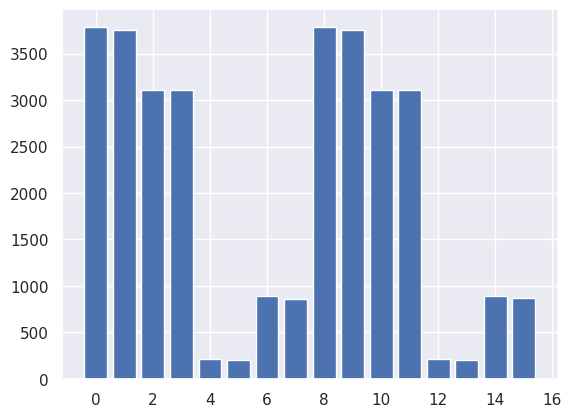

In [ ]:
R = np.loadtxt("hmax.txt")
plt.bar(x=np.arange(R.size), height=R)
plt.show()

In [ ]:
Half_effects = np.linalg.solve(M.T @ M, M.T @ R)
Rel_effects = Half_effects / Half_effects[0]

beta = 0.95
alpha = 1-beta
dof = M.shape[0] - M.shape[1]
t_student = sp_t.ppf(beta + alpha/2, dof)

residue = R - M @ Half_effects
var_exp = residue.T @ residue /(dof)
D3 = np.linalg.inv(M.T @ M)
CI = t_student * np.sqrt(np.diag(D3) * var_exp)

display(pd.DataFrame(
  np.round(np.vstack((Half_effects.T, CI.T, Rel_effects.T)), 2),
    index=["Half-effects", f"{beta:.0%} CI", "Relative"],
    columns=M.columns
))


NameError: name 'sp_t' is not defined